In [1]:
# 0) Add autoreload so code changes pick up automatically
%load_ext autoreload
%autoreload 2

import os
import sys
import numpy as np
import pandas as pd
from sqlalchemy import create_engine

# --- 1. Setup ---
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from algogators_wrisk import config, features, analysis

# Connection
conn_str = f"postgresql+psycopg://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}@{os.environ['DB_HOST']}:5432/{os.environ['DB_NAME']}"
engine = create_engine(conn_str)

def fetch_data(symbols, start, end):
    price_series = []
    for symbol in symbols:
        query = f"SELECT time, close FROM {config.DB_SCHEMA}.{config.PRICES_TABLE} WHERE symbol = '{symbol}' AND time BETWEEN '{start}' AND '{end}' ORDER BY time ASC"
        df = pd.read_sql(query, engine)
        if not df.empty:
            df['time'] = pd.to_datetime(df['time']).dt.floor('D')
            s = df.set_index('time')['close'].rename(symbol)
            price_series.append(s[~s.index.duplicated(keep='last')])
    
    if not price_series:
        raise ValueError("No data found. Verify your config.py symbols and table names.")
        
    return pd.concat(price_series, axis=1).sort_index().ffill().dropna()

# --- 2. Execution ---
print("--- Loading Data ---")
all_data = fetch_data(config.UNIVERSE, config.START_DATE, config.END_DATE)

# Separate Universe prices from Macro Treasuries
prices = all_data.drop(columns=['ZT', 'ZF'], errors='ignore')
df_macro = all_data[['ZT', 'ZF']].rename(columns={'ZT': 'treas_2y_close', 'ZF': 'treas_5y_close'})

print(f"✅ Success! Data loaded for: {list(prices.columns)}")

# --- 3. Analysis ---
# Calculate returns
returns = np.log(prices).diff().dropna()

# Build the Core Panel 
# (This computes the Wasserstein 'W' index and Lambda1 internally)
panel = analysis.build_core_panel(
    returns,
    rv_past_window=config.RV_PAST_WINDOW,
    rv_future_window=config.RV_FUTURE_WINDOW,
    lambda1_window=config.LAMBDA1_WINDOW
)

# Join Macro data
panel = panel.join(df_macro, how='inner').dropna()

# Run the RV Regression using library function
results = analysis.run_rv_regression(
    panel,
    hac_lags=config.HAC_LAGS
)

print("\n--- Wasserstein Risk Index Regression ---")
print(results.summary())

--- Loading Data ---


/tmp/ipykernel_18535/3055648300.py:35: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  return pd.concat(price_series, axis=1).sort_index().ffill().dropna()


✅ Success! Data loaded for: ['NG', '6L', '6A', 'HO']

--- Wasserstein Risk Index Regression ---
                            OLS Regression Results                            
Dep. Variable:              rv_future   R-squared:                       0.371
Model:                            OLS   Adj. R-squared:                  0.371
Method:                 Least Squares   F-statistic:                     107.8
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           1.50e-66
Time:                        04:06:03   Log-Likelihood:                 4999.0
No. Observations:                3293   AIC:                            -9990.
Df Residuals:                    3289   BIC:                            -9966.
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------

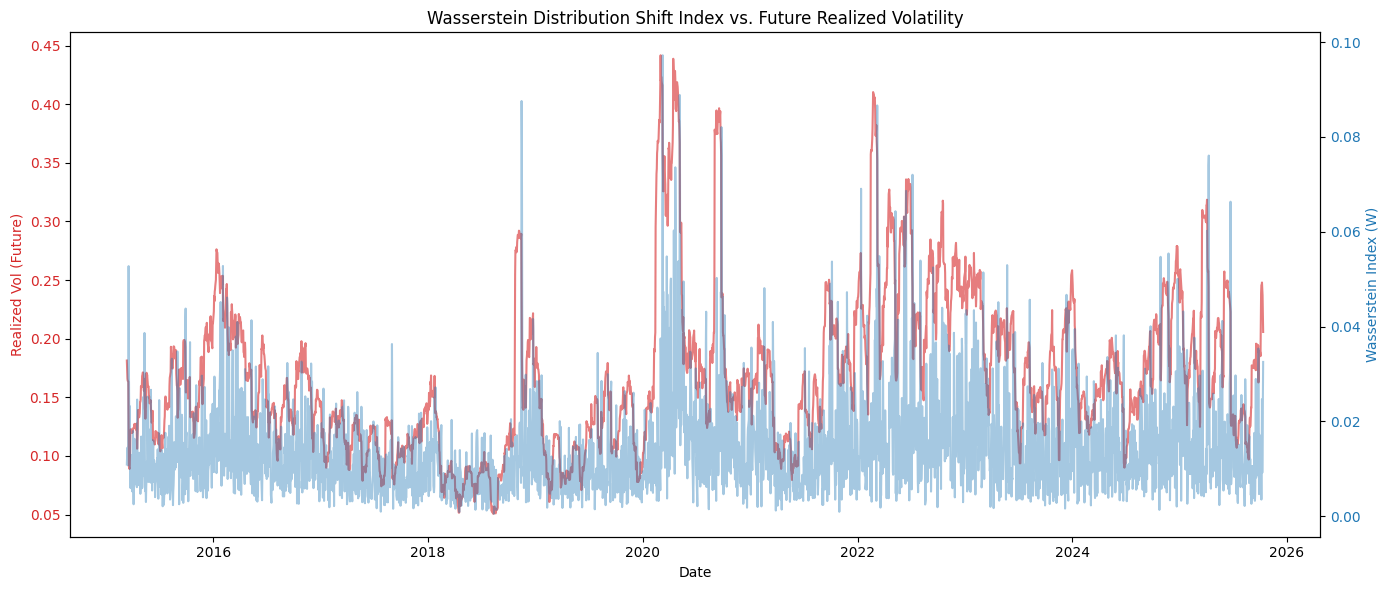

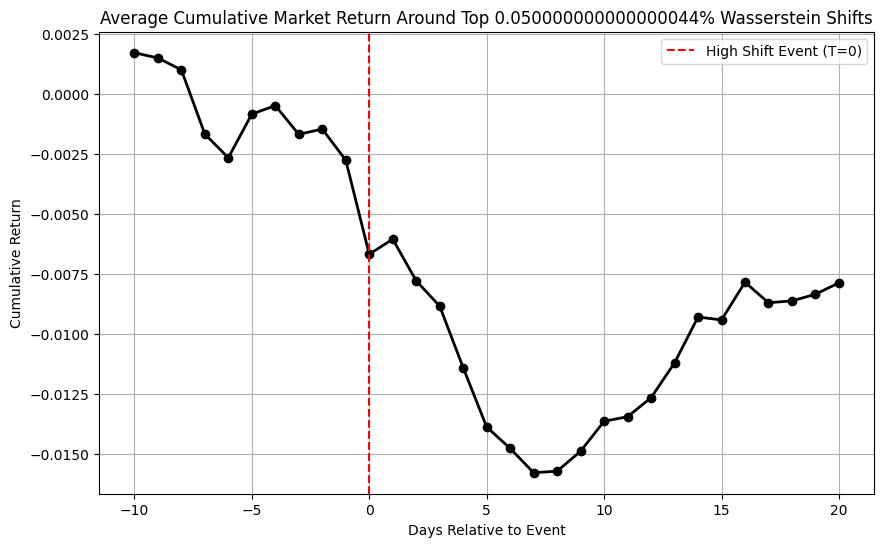

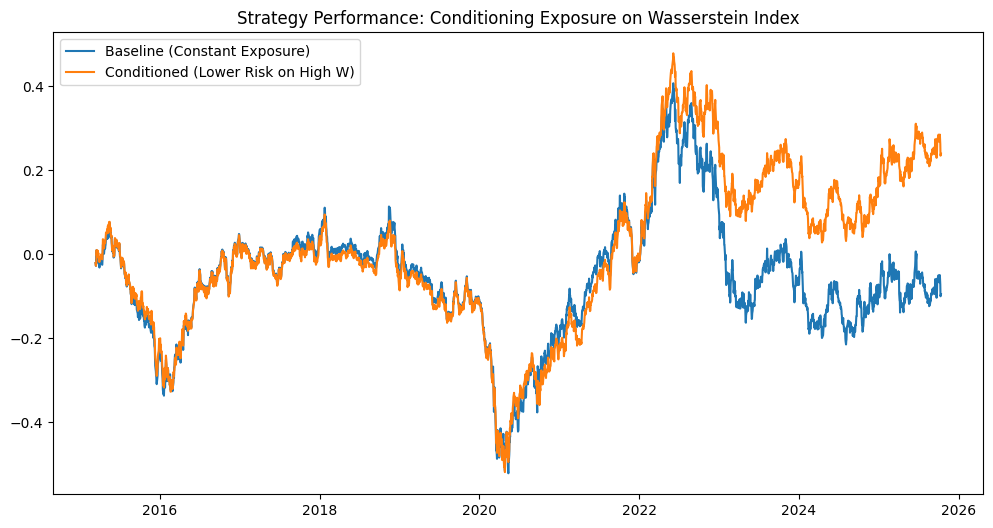

In [2]:
import matplotlib.pyplot as plt

# --- 1. Visualize the Wasserstein Index vs Future Vol ---
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.set_xlabel('Date')
ax1.set_ylabel('Realized Vol (Future)', color='tab:red')
ax1.plot(panel.index, panel['rv_future'], color='tab:red', alpha=0.6, label='Forward RV (20d)')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Wasserstein Index (W)', color='tab:blue')
ax2.plot(panel.index, panel['W'], color='tab:blue', alpha=0.4, label='Wasserstein Index')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Wasserstein Distribution Shift Index vs. Future Realized Volatility')
fig.tight_layout()
plt.show()

# --- 2. Event Study: Cumulative Returns around High-W Days ---
# This uses the built-in event study logic from your analysis.py
event_result = analysis.make_event_study_dataset(
    panel, 
    w_col='W', 
    value_col='mkt_ret', 
    quantile=config.W_EVENT_QUANTILE,
    pre=10, 
    post=20
)

if not event_result.stacked.empty:
    plt.figure(figsize=(10, 6))
    # Convert daily returns to cumulative growth for the plot
    avg_cum_ret = event_result.avg_path.cumsum() 
    plt.plot(avg_cum_ret.index, avg_cum_ret.values, marker='o', color='black', linewidth=2)
    plt.axvline(0, color='red', linestyle='--', label='High Shift Event (T=0)')
    plt.title(f'Average Cumulative Market Return Around Top {1-config.W_EVENT_QUANTILE}% Wasserstein Shifts')
    plt.xlabel('Days Relative to Event')
    plt.ylabel('Cumulative Return')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No events found for the specified quantile.")

# --- 3. Strategy Experiment ---
# See if scaling down exposure on high-W days helps performance
strat_results = analysis.run_strategy_conditioning_experiment(
    panel, 
    quantile=config.W_EVENT_QUANTILE,
    exposure_on_event=config.EXPOSURE_ON_EVENT
)

plt.figure(figsize=(12, 6))
plt.plot(strat_results.index, strat_results['baseline_cum'], label='Baseline (Constant Exposure)')
plt.plot(strat_results.index, strat_results['conditioned_cum'], label='Conditioned (Lower Risk on High W)')
plt.title('Strategy Performance: Conditioning Exposure on Wasserstein Index')
plt.legend()
plt.show()